# Tumor RNA-seq reference-space PCA and Hoshida classification


This notebook places paired HCC biopsy and resection transcriptomes alongside
an external tumor classification cohort. It combines compatible count matrices,
retains protein-coding genes, applies VST, and evaluates paired sample displacement
in two complementary PCA constructions: a PCA fitted on the biopsy reference
cohort and a PCA fitted on the combined reference and study samples. The latter part prepares and visualizes
Hoshida molecular-subtype analyses.

**Primary inputs**

- `../counts_080725.out`: biopsy/resection featureCounts table.
- `../counts_with_class.out`: external tumor reference/classification count table.
- `../sample_mapping_BvR.csv`: paired study sample mapping.
- `sample_mapping_with_classification.csv`: reference-cohort tumor-content metadata.
- Ensembl biotype/gene mapping pickle files and Hoshida subtype/classification files.

**Key retained decisions**

- Tumor RNA-seq columns (`*_tu_transcriptome`) are used for the paired study cohort.
- Patients M and C are excluded in the original selection code.
- Protein-coding genes with at least 10 counts in at least three samples are retained.
- PCA distance and permutation analyses use the 500 most variable genes and up to 10 PCs.
- Hoshida labels with BH FDR greater than 0.05 are marked unclassifiable.


## 1. Environment and imports

Load count-processing, clustering, PCA, plotting, and PyDESeq2 dependencies.

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import math
import pickle
from pprint import pprint
import itertools

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import percentileofscore

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.pyplot import gcf
from matplotlib import cm, colors
from matplotlib.patches import Patch

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

## 2. Select paired tumor samples

Load the mapping, retain complete HCC tumor pairs, and apply the original patient exclusions.

In [42]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
rna_cols = ['Biopsy_tu_transcriptome', 'Resection_tu_transcriptome']
meta = meta.dropna(subset=rna_cols)
meta = meta[(meta['Patient ID'] != 'M') & (meta['Patient ID'] != 'M')]
meta = meta[(meta['Patient ID'] != 'C') & (meta['Patient ID'] != 'C')]
meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
3,B,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,M,12.0,53.0,55.0,46.0,137.0,36.0,43.0,72.0,141.0,4.0,54.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,70.0,43.0,NaN,HCC,84.0,94.0,16.0,6.0,86.0,99.0,8.0,0.0,0.0,1.0,5.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,49.0,M,6.0,30.0,29.0,59.0,53.0,38.0,13.0,103.0,161.0,6.0,196.0,1.0,2.0,6.0,25.0,26.0,49.0,56.0,39.0,5.0,115.0,154.0,5.0,209.0,1.0,NaN,NaN,A,1,35.0,11.0,212.0,HCC,99.0,97.0,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0
15,H,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129480,BSSE_QGF_129481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,F,11.0,24.0,31.0,23.0,80.0,33.0,25.0,65.0,127.0,4.0,87.0,1.0,NaN,9.0,28.0,35.0,53.0,95.0,36.0,21.0,69.0,117.0,4.0,98.0,NaN,NaN,NaN,A,1,50.0,20.0,64.0,HCC,68.0,82.0,32.0,18.0,98.0,96.0,2.0,4.0,0.0,0.0,0.0,0.0


## 3. Load and combine study/reference counts

Read the paired-study and external-reference count matrices, standardize identifiers, and concatenate the samples.

In [43]:
# Import data

raw_bvr = pd.read_csv('../counts_080725.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_bvr = raw_bvr.iloc[:,5:]
# Change column names
raw_bvr.columns = raw_bvr.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')

# Check if we have all rna seq samples in the counts table
found = []
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw_bvr.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)
            
# Extras
extras = []
for seq_id in raw_bvr.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
raw_bvr = raw_bvr.drop(extras, axis=1)

raw_bvr.head()

extra: BSSE_QGF_129466
extra: BSSE_QGF_129468
extra: BSSE_QGF_129474
extra: BSSE_QGF_129476
extra: BSSE_QGF_129478
extra: BSSE_QGF_129480
extra: BSSE_QGF_129482
extra: BSSE_QGF_145457
extra: BSSE_QGF_145458
extra: BSSE_QGF_145460
extra: BSSE_QGF_145462
extra: BSSE_QGF_145465
extra: BSSE_QGF_145466
extra: BSSE_QGF_145472
extra: BSSE_QGF_145474
extra: BSSE_QGF_145476
extra: BSSE_QGF_145478
extra: BSSE_QGF_145480
extra: BSSE_QGF_145481
extra: BSSE_QGF_182046
extra: BSSE_QGF_182047
extra: BSSE_QGF_182048
extra: BSSE_QGF_182049
extra: BSSE_QGF_182052
extra: BSSE_QGF_182054
extra: BSSE_QGF_182056
extra: BSSE_QGF_182057
extra: BSSE_QGF_182064
extra: BSSE_QGF_182066
extra: BSSE_QGF_182070
extra: BSSE_QGF_182072
extra: BSSE_QGF_182074
extra: BSSE_QGF_182076
extra: BSSE_QGF_182080
extra: BSSE_QGF_182081
extra: BSSE_QGF_182082
extra: BSSE_QGF_182084
extra: BSSE_QGF_182087
extra: BSSE_QGF_182088
extra: BSSE_QGF_182091
extra: BSSE_QGF_182092
extra: BSSE_QGF_182098
extra: BSSE_QGF_182100
extra: BSSE

,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_55730,BSSE_QGF_55744
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,491,217
ENSG00000279928,1,3,1,22,1,32,3,1,0,0,0,3,2,0,0,10,0,0,0,1,0,5,1,3,0,3,2,0,4,1
ENSG00000228037,11,0,13,17,2,9,6,3,6,7,19,20,11,25,10,18,11,8,10,19,18,24,7,16,7,2,43,3,16,12
ENSG00000142611,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,73,66
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6


In [44]:
# Import data

raw_class = pd.read_csv('../counts_with_class.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_class = raw_class.iloc[:,5:]
# Change column names
raw_class.columns = raw_class.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw_class.head()

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,989,301,895,316,275,1344,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,130,221,201,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000279928,2,3,1,0,3,3,0,0,3,0,1,4,1,0,1,2,2,0,1,1,1,1,0,4,1,0,1,0,3,1,2,1,2,3,0,3,2,3,1,1,3,1,3,7,8,3,1,0,1,3,0,0,0,3,3,0,2,1,2,1,0,0,1,0,4,3,7,8,0,3,2,0,0,0,1,5,1,5,0,4,3,0,0,3,1,0,2,0,1,4,0,0,1,2,3,2,3,2,0,3,0,0,1,2,4,3,9,2,6,3,6,0,15,1,6
ENSG00000228037,13,16,27,27,13,35,11,1,7,9,10,8,8,14,3,13,18,10,9,8,6,13,7,18,10,10,18,3,13,12,14,23,6,8,7,10,4,10,9,22,8,1,20,27,21,8,23,3,13,19,10,17,15,12,12,9,15,1,6,12,15,47,7,10,81,13,25,54,5,20,12,22,19,7,6,12,3,14,7,35,8,16,16,11,12,20,26,18,39,27,26,8,18,35,25,21,14,27,10,15,9,3,8,5,7,8,10,15,22,5,31,14,21,48,54
ENSG00000142611,4,3,674,11,191,7,92,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,8,3,7,4,3,14,2,1,0,3,14,0,12,53,31,302,1187
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [45]:
# combine counts tables

raw = pd.concat([raw_bvr, raw_class], axis=1)
raw.head()

,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_55730,BSSE_QGF_55744,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,491,217,989,301,895,316,275,1344,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,130,221,201,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000279928,1,3,1,22,1,32,3,1,0,0,0,3,2,0,0,10,0,0,0,1,0,5,1,3,0,3,2,0,4,1,2,3,1,0,3,3,0,0,3,0,1,4,1,0,1,2,2,0,1,1,1,1,0,4,1,0,1,0,3,1,2,1,2,3,0,3,2,3,1,1,3,1,3,7,8,3,1,0,1,3,0,0,0,3,3,0,2,1,2,1,0,0,1,0,4,3,7,8,0,3,2,0,0,0,1,5,1,5,0,4,3,0,0,3,1,0,2,0,1,4,0,0,1,2,3,2,3,2,0,3,0,0,1,2,4,3,9,2,6,3,6,0,15,1,6
ENSG00000228037,11,0,13,17,2,9,6,3,6,7,19,20,11,25,10,18,11,8,10,19,18,24,7,16,7,2,43,3,16,12,13,16,27,27,13,35,11,1,7,9,10,8,8,14,3,13,18,10,9,8,6,13,7,18,10,10,18,3,13,12,14,23,6,8,7,10,4,10,9,22,8,1,20,27,21,8,23,3,13,19,10,17,15,12,12,9,15,1,6,12,15,47,7,10,81,13,25,54,5,20,12,22,19,7,6,12,3,14,7,35,8,16,16,11,12,20,26,18,39,27,26,8,18,35,25,21,14,27,10,15,9,3,8,5,7,8,10,15,22,5,31,14,21,48,54
ENSG00000142611,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,73,66,4,3,674,11,191,7,92,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,8,3

In [46]:
raw_bvr.shape

(62703, 30)

In [47]:
raw_class.shape

(62703, 115)

In [48]:
raw.shape

(62703, 145)

## 4. Annotate and filter protein-coding genes

Map Ensembl biotypes and retain protein-coding genes.

In [50]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = raw.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc = df_pc.drop('Biotype', axis=1)
df_pc.index.name = None
df_pc.shape

(20056, 145)

## 5. Construct combined metadata

Reshape biopsy/resection metadata, append reference samples, and map reference-cohort tumor content.

In [51]:
# Create metadata for Deseq
meta_rna = meta.loc[:,['Patient ID', 'Biopsy_tu_transcriptome',
                       'Resection_tu_transcriptome','Age', 'Sex']].copy()
meta_rna = meta_rna.melt(id_vars=['Patient ID', 'Age', 'Sex'],
                         value_vars=['Biopsy_tu_transcriptome',
                                     'Resection_tu_transcriptome',])
meta_rna['Sample_type'] = meta_rna.variable.str.split('_').str[0]
meta_rna = meta_rna.drop('variable', axis=1)
meta_rna = meta_rna.rename({'value':'Seq_id'}, axis=1)
meta_rna.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
0,B,59.0,M,BSSE_QGF_129467,Biopsy
1,D,70.0,F,BSSE_QGF_182053,Biopsy
2,E,79.0,M,BSSE_QGF_145477,Biopsy
3,F,49.0,M,BSSE_QGF_145473,Biopsy
4,H,69.0,F,BSSE_QGF_129477,Biopsy


In [52]:
raw_class.columns

Index(['BSSE_QGF_107014', 'BSSE_QGF_107024', 'BSSE_QGF_107028',
       'BSSE_QGF_107037', 'BSSE_QGF_107047', 'BSSE_QGF_107058',
       'BSSE_QGF_107063', 'BSSE_QGF_34365', 'BSSE_QGF_34369', 'BSSE_QGF_34371',
       ...
       'BSSE_QGF_55763', 'BSSE_QGF_55774', 'BSSE_QGF_79904', 'BSSE_QGF_79908',
       'GFB_37105', 'GFB_37107', 'GFB_37108', 'GFB_37111', 'GFB_37113',
       'GFB_37117'],
      dtype='object', length=115)

In [53]:
metadata = meta_rna.copy()
metadata.index = metadata.Seq_id

metadata = pd.concat([metadata, pd.DataFrame(raw_class.columns, columns=['Seq_id'])])
metadata.Sample_type = metadata.Sample_type.fillna('Class')
metadata.tail()

,Patient ID,Age,Sex,Seq_id,Sample_type
110,NaN,NaN,NaN,GFB_37107,Class
111,NaN,NaN,NaN,GFB_37108,Class
112,NaN,NaN,NaN,GFB_37111,Class
113,NaN,NaN,NaN,GFB_37113,Class
114,NaN,NaN,NaN,GFB_37117,Class


In [54]:
add_meta_class = pd.read_csv('sample_mapping_with_classification.csv', index_col = 'RNA_seq_code')
metadata['percent_tumor'] = metadata.Seq_id.map(add_meta_class.percent_tumor)
metadata = metadata.reset_index(drop=True)
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
0,B,59.0,M,BSSE_QGF_129467,Biopsy,NaN
1,D,70.0,F,BSSE_QGF_182053,Biopsy,NaN
2,E,79.0,M,BSSE_QGF_145477,Biopsy,NaN
3,F,49.0,M,BSSE_QGF_145473,Biopsy,NaN
4,H,69.0,F,BSSE_QGF_129477,Biopsy,NaN


In [55]:
df_pc.columns

Index(['BSSE_QGF_129467', 'BSSE_QGF_129469', 'BSSE_QGF_129475',
       'BSSE_QGF_129477', 'BSSE_QGF_129479', 'BSSE_QGF_129481',
       'BSSE_QGF_145461', 'BSSE_QGF_145463', 'BSSE_QGF_145473',
       'BSSE_QGF_145475',
       ...
       'BSSE_QGF_55763', 'BSSE_QGF_55774', 'BSSE_QGF_79904', 'BSSE_QGF_79908',
       'GFB_37105', 'GFB_37107', 'GFB_37108', 'GFB_37111', 'GFB_37113',
       'GFB_37117'],
      dtype='object', length=145)

## 6. Low-count filtering and VST

Retain genes expressed at the required threshold, align counts to metadata, and calculate VST values.

In [56]:
# Filtering

# Create a copy to work on
df_pc_ = df_pc.copy()

# Apply the filter criteria
for col in df_pc_.columns:
    df_pc_[col] = np.where(df_pc_[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_[df_pc_.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_ = df_pc.loc[keep_indices_].copy()

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_1668\562405431.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)


In [57]:
df_pc_.columns

Index(['BSSE_QGF_129467', 'BSSE_QGF_129469', 'BSSE_QGF_129475',
       'BSSE_QGF_129477', 'BSSE_QGF_129479', 'BSSE_QGF_129481',
       'BSSE_QGF_145461', 'BSSE_QGF_145463', 'BSSE_QGF_145473',
       'BSSE_QGF_145475',
       ...
       'BSSE_QGF_55763', 'BSSE_QGF_55774', 'BSSE_QGF_79904', 'BSSE_QGF_79908',
       'GFB_37105', 'GFB_37107', 'GFB_37108', 'GFB_37111', 'GFB_37113',
       'GFB_37117'],
      dtype='object', length=145)

In [58]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
0,B,59.0,M,BSSE_QGF_129467,Biopsy,NaN
1,D,70.0,F,BSSE_QGF_182053,Biopsy,NaN
2,E,79.0,M,BSSE_QGF_145477,Biopsy,NaN
3,F,49.0,M,BSSE_QGF_145473,Biopsy,NaN
4,H,69.0,F,BSSE_QGF_129477,Biopsy,NaN


In [59]:
# Same sorting
metadata = metadata.sort_values('Seq_id')
metadata.index = metadata.Seq_id
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
Seq_id,,,,,,
BSSE_QGF_107014,NaN,NaN,NaN,BSSE_QGF_107014,Class,100.0
BSSE_QGF_107024,NaN,NaN,NaN,BSSE_QGF_107024,Class,90.0
BSSE_QGF_107028,NaN,NaN,NaN,BSSE_QGF_107028,Class,60.0
BSSE_QGF_107037,NaN,NaN,NaN,BSSE_QGF_107037,Class,95.0
BSSE_QGF_107047,NaN,NaN,NaN,BSSE_QGF_107047,Class,60.0


In [60]:
df_pc.head()

,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_55730,BSSE_QGF_55744,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
ENSG00000160072,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,491,217,989,301,895,316,275,1344,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,130,221,201,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000142611,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,73,66,4,3,674,11,191,7,92,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,8,3,7,4,3,14,2,1,0,3,14,0,12,53,31,302,1187
ENSG00000157911,449,372,472,129,236,168,137,102,263,231,215,182,296,223,362,470,182,184,420,320,293,155,192,248,92,391,275,102,214,90,373,292,575,184,167,907,334,52,364,513,157,254,104,403,198,425,314,561,301,398,623,405,409,529,160,480,225,263,211,440,894,355,452,207,247,186,648,222,190,296,421,262,383,511,254,290,389,222,295,199,79,379,463,320,368,515,345,450,135,219,72,200,120,70,134,178,856,340,296,152,113,204,150,163,259,155,295,103,116,363,216,284,324,131,134,75,120,150,87,161,258,326,144,231,149,192,98,310,117,114,125,73,81,87,137,109,75,680,505,397,941,990,492,520,830
ENSG00000142655,193,160,797,273,471,197,361,322,491,467,326,321,509,354,495,545,296,470,303,146,568,407,359,151,135,548,720,72,258,162,523,252,528,381,53,313,813,68,458,454,165,271,109,382,291,484,231,522,342,473,498,558,245,442,253,562,18

In [61]:
df_pc_ = df_pc_.loc[:,metadata.Seq_id]
df_pc_.head()

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55730,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55744,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
ENSG00000160072,989,301,895,316,275,1344,279,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,491,130,221,201,217,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000142611,4,3,674,11,191,7,92,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,73,8,3,7,66,4,3,14,2,1,0,3,14,0,12,53,31,302,1187
ENSG00000157911,373,292,575,184,167,907,334,449,372,472,129,236,168,137,102,263,231,215,182,296,223,362,470,182,184,420,320,293,155,192,248,92,391,275,102,52,364,513,157,254,104,403,198,425,314,561,301,398,623,405,409,529,160,480,225,263,211,440,894,355,452,207,247,186,648,222,190,296,421,262,383,511,254,290,389,222,295,199,79,379,463,320,368,515,345,450,135,219,72,200,120,70,134,178,856,340,296,152,113,204,150,163,259,155,295,103,116,363,216,284,324,131,134,75,120,150,87,161,258,326,144,231,149,192,98,310,214,117,114,125,90,73,81,87,137,109,75,680,505,397,941,990,492,520,830
ENSG00000142655,523,252,528,381,53,313,813,193,160,797,273,471,197,361,322,491,467,326,321,509,354,495,545,296,470,303,146,568,407,359,151,135,548,720,72,68,458,454,165,271,109,382,291,484,231,522,342,473,498,558,245,442,253,562,185,362,36

In [62]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_.T,
    metadata=metadata,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~ Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_.T.index, columns=df_pc_.T.columns
)
df_vst = transformed_counts.T

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.93 seconds.

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.89 seconds.

Fitting dispersions...
... done in 69.85 seconds.



In [63]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
Seq_id,,,,,,
BSSE_QGF_107014,NaN,NaN,NaN,BSSE_QGF_107014,Class,100.0
BSSE_QGF_107024,NaN,NaN,NaN,BSSE_QGF_107024,Class,90.0
BSSE_QGF_107028,NaN,NaN,NaN,BSSE_QGF_107028,Class,60.0
BSSE_QGF_107037,NaN,NaN,NaN,BSSE_QGF_107037,Class,95.0
BSSE_QGF_107047,NaN,NaN,NaN,BSSE_QGF_107047,Class,60.0


## 7. Exploratory PCA

Select the 500 most variable genes, scale samples, fit the exploratory two-component PCA, and visualize group and patient structure.

In [64]:
# Subset classification samples

df_class = df_vst.loc[:,metadata[metadata.Sample_type == 'Class'].index].copy()
df_bvr = df_vst.loc[:,metadata[metadata.Sample_type != 'Class'].index].copy()

In [65]:
# 500 most variable genes 
df_bvr_ = df_bvr.copy()
df_bvr_['std_genes'] = df_bvr_.std(axis=1)
most_var_genes = df_bvr_.sort_values('std_genes', ascending=False).iloc[0:500,:].index
most_var_genes

Index(['ENSG00000160868', 'ENSG00000147604', 'ENSG00000132693',
       'ENSG00000177954', 'ENSG00000130649', 'ENSG00000198074',
       'ENSG00000181019', 'ENSG00000067048', 'ENSG00000255974',
       'ENSG00000264424',
       ...
       'ENSG00000039068', 'ENSG00000166681', 'ENSG00000149948',
       'ENSG00000148123', 'ENSG00000111249', 'ENSG00000137077',
       'ENSG00000001626', 'ENSG00000169245', 'ENSG00000124212',
       'ENSG00000134463'],
      dtype='object', length=500)

In [66]:
# scaled data

scaler = StandardScaler()
scaler.fit(df_class.loc[most_var_genes,:].T)
scaled_data_class = scaler.transform(df_class.loc[most_var_genes,:].T)
scaled_data = scaler.transform(df_vst.loc[most_var_genes,:].T)


In [67]:
pca = PCA(n_components=2)

# Fit only on classification samples
pca.fit(scaled_data_class)
projections = pca.transform(scaled_data)

# fit on all including BvR samples
#projections = pca.fit_transform(scaled_data)

In [68]:
hue_order=['Biopsy', 'Resection', 'Class']

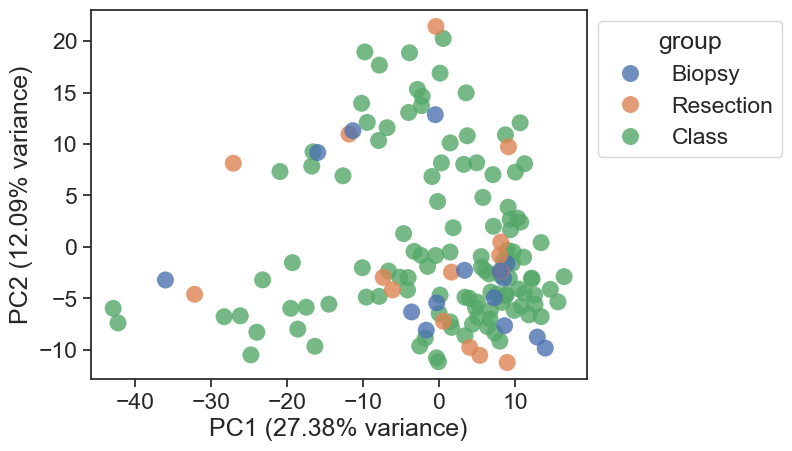

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_1668\3073344457.py:24: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


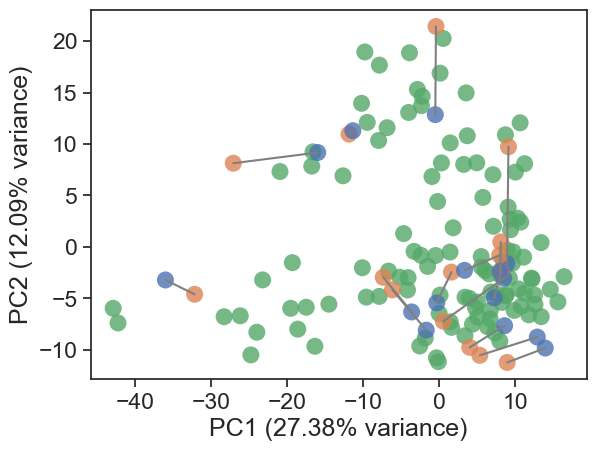

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_1668\3073344457.py:35: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


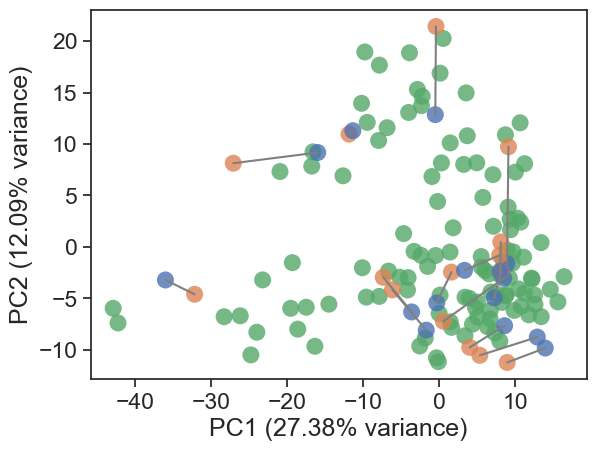

In [69]:
df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2'], index=df_vst.columns)
df_pca['group'] = metadata.Sample_type
df_pca['patient_id'] = metadata['Patient ID'].astype(str)

# sort to get classification samples below
df_pca = df_pca.sort_values('patient_id', ascending=False)

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, linewidth=0, hue_order = hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
xlim = g.get_xlim()
ylim = g.get_ylim()
#plt.savefig('PCA_classification.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, linewidth=0, hue_order=hue_order)
h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
#plt.savefig('PCA_classification_pat.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, linewidth=0, hue_order=hue_order)
h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
#plt.savefig('PCA_classification_pat.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


# Part I — Quantifying paired displacement in PCA space

Evaluate whether biopsy and resection profiles differ relative to external tumor-reference variability.

In [70]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
Seq_id,,,,,,
BSSE_QGF_107014,NaN,NaN,NaN,BSSE_QGF_107014,Class,100.0
BSSE_QGF_107024,NaN,NaN,NaN,BSSE_QGF_107024,Class,90.0
BSSE_QGF_107028,NaN,NaN,NaN,BSSE_QGF_107028,Class,60.0
BSSE_QGF_107037,NaN,NaN,NaN,BSSE_QGF_107037,Class,95.0
BSSE_QGF_107047,NaN,NaN,NaN,BSSE_QGF_107047,Class,60.0


In [71]:
# Your expression matrix: genes x samples
# Replace this with your actual dataframe name
expr = df_vst.copy()

# Metadata from your screenshot
meta = metadata.copy()

sample_col = "Seq_id"
patient_col = "Patient ID"
sample_type_col = "Sample_type"

REF_LABEL = "Class"
BIOPSY_LABEL = "Biopsy"
RESECTION_LABEL = "Resection"

N_TOP_GENES = 500
N_PCS = 10
N_PERM = 9999
RANDOM_STATE = 1

In [72]:
# Make sure metadata index is Seq_id
if meta.index.name != sample_col:
    meta = meta.set_index(sample_col, drop=False)

# Remove accidental whitespace
meta[sample_type_col] = meta[sample_type_col].astype(str).str.strip()
meta[sample_col] = meta[sample_col].astype(str).str.strip()

expr.columns = expr.columns.astype(str).str.strip()
expr.index = expr.index.astype(str).str.strip()

# Keep only samples present in both expression matrix and metadata
common_samples = expr.columns.intersection(meta.index)

expr = expr.loc[:, common_samples]
meta = meta.loc[common_samples]

print(expr.shape)
print(meta[sample_type_col].value_counts())

(17738, 145)
Sample_type
Class        115
Biopsy        15
Resection     15
Name: count, dtype: int64


In [73]:
ref_samples = meta.index[meta[sample_type_col] == REF_LABEL]
study_samples = meta.index[meta[sample_type_col].isin([BIOPSY_LABEL, RESECTION_LABEL])]

# Convert from genes x samples to samples x genes
ref_expr = expr.loc[:, ref_samples].T
study_expr = expr.loc[:, study_samples].T

study_meta = meta.loc[study_samples].copy()
ref_meta = meta.loc[ref_samples].copy()

print("Reference expression:", ref_expr.shape)
print("Study expression:", study_expr.shape)
print(study_meta[sample_type_col].value_counts())

Reference expression: (115, 17738)
Study expression: (30, 17738)
Sample_type
Biopsy       15
Resection    15
Name: count, dtype: int64


## 8. Reference-fitted PCA

Fit scaling and PCA only on external reference tumors, then project the paired study samples without refitting.

In [74]:
def fit_reference_pca_and_project(
    ref_expr,
    study_expr,
    n_top_genes=500,
    n_pcs=10,
    random_state=1,
):
    """
    ref_expr: samples x genes
    study_expr: samples x genes

    Fits PCA on reference samples using top variable genes,
    then projects study biopsy/resection samples into that PCA space.
    """

    common_genes = ref_expr.columns.intersection(study_expr.columns)

    ref_common = ref_expr.loc[:, common_genes]
    study_common = study_expr.loc[:, common_genes]

    n_top_genes = min(n_top_genes, len(common_genes))

    top_genes = (
        ref_common.var(axis=0)
        .sort_values(ascending=False)
        .head(n_top_genes)
        .index
    )

    scaler = StandardScaler(with_mean=True, with_std=True)

    ref_scaled = scaler.fit_transform(ref_common.loc[:, top_genes])
    study_scaled = scaler.transform(study_common.loc[:, top_genes])

    max_pcs = min(n_pcs, ref_scaled.shape[0] - 1, ref_scaled.shape[1])

    pca = PCA(n_components=max_pcs, random_state=random_state)

    ref_scores_array = pca.fit_transform(ref_scaled)
    study_scores_array = pca.transform(study_scaled)

    pc_cols = [f"PC{i+1}" for i in range(max_pcs)]

    ref_scores = pd.DataFrame(
        ref_scores_array,
        index=ref_expr.index,
        columns=pc_cols,
    )

    study_scores = pd.DataFrame(
        study_scores_array,
        index=study_expr.index,
        columns=pc_cols,
    )

    return ref_scores, study_scores, pca, scaler, top_genes

In [75]:
ref_scores, study_scores_refspace, ref_pca, ref_scaler, ref_top_genes = (
    fit_reference_pca_and_project(
        ref_expr=ref_expr,
        study_expr=study_expr,
        n_top_genes=N_TOP_GENES,
        n_pcs=N_PCS,
        random_state=RANDOM_STATE,
    )
)

pd.Series(
    ref_pca.explained_variance_ratio_,
    index=ref_scores.columns,
    name="explained_variance_ratio",
)

PC1     0.296440
PC2     0.123956
PC3     0.051633
PC4     0.041326
PC5     0.039558
PC6     0.025888
PC7     0.023719
PC8     0.018989
PC9     0.017653
PC10    0.017031
Name: explained_variance_ratio, dtype: float64

## 9. Matched-pair distances in reference space

Calculate biopsy/resection distances and compare them with distances among reference tumors.

In [76]:
def matched_pair_distances(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates matched biopsy-to-resection Euclidean distances
    for each patient in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        dist = np.linalg.norm(
            scores.loc[b, pc_cols].values -
            scores.loc[r, pc_cols].values
        )

        rows.append({
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "matched_distance": dist,
        })

    return pd.DataFrame(rows)

In [77]:
pc_cols = [f"PC{i+1}" for i in range(min(N_PCS, ref_scores.shape[1]))]

matched_refspace = matched_pair_distances(
    scores=study_scores_refspace,
    meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=pc_cols,
)

matched_refspace

,Patient ID,biopsy_sample,resection_sample,n_pcs,matched_distance
0,B,BSSE_QGF_129467,BSSE_QGF_129469,10,6.296727
1,D,BSSE_QGF_182053,BSSE_QGF_182083,10,6.253455
2,E,BSSE_QGF_145477,BSSE_QGF_145479,10,10.226007
3,F,BSSE_QGF_145473,BSSE_QGF_145475,10,7.619094
4,H,BSSE_QGF_129477,BSSE_QGF_129481,10,12.130925
5,I,BSSE_QGF_182073,BSSE_QGF_182107,10,7.749971
6,J,BSSE_QGF_182065,BSSE_QGF_182099,10,8.685087
7,K,BSSE_QGF_129475,BSSE_QGF_129479,10,15.630076
8,L,BSSE_QGF_145461,BSSE_QGF_145463,10,5.421484
9,N,BSSE_QGF_182055,BSSE_QGF_182085,10,7.842932


In [78]:
# Pairwise distances among all Class/reference samples
ref_pairwise_distances = pdist(
    ref_scores.loc[:, pc_cols].values,
    metric="euclidean",
)

print("Number of reference pairwise distances:", len(ref_pairwise_distances))

Number of reference pairwise distances: 6555


In [79]:
matched_refspace_benchmarked = matched_refspace.copy()

matched_refspace_benchmarked["reference_percentile"] = [
    percentileofscore(ref_pairwise_distances, d, kind="rank")
    for d in matched_refspace_benchmarked["matched_distance"]
]

matched_refspace_benchmarked["empirical_p_far_vs_reference"] = [
    (1 + np.sum(ref_pairwise_distances >= d)) / (1 + len(ref_pairwise_distances))
    for d in matched_refspace_benchmarked["matched_distance"]
]

matched_refspace_benchmarked

,Patient ID,biopsy_sample,resection_sample,n_pcs,matched_distance,reference_percentile,empirical_p_far_vs_reference
0,B,BSSE_QGF_129467,BSSE_QGF_129469,10,6.296727,0.335622,0.996644
1,D,BSSE_QGF_182053,BSSE_QGF_182083,10,6.253455,0.335622,0.996644
2,E,BSSE_QGF_145477,BSSE_QGF_145479,10,10.226007,4.195271,0.958054
3,F,BSSE_QGF_145473,BSSE_QGF_145475,10,7.619094,0.778032,0.992221
4,H,BSSE_QGF_129477,BSSE_QGF_129481,10,12.130925,8.543097,0.914582
5,I,BSSE_QGF_182073,BSSE_QGF_182107,10,7.749971,0.839054,0.991611
6,J,BSSE_QGF_182065,BSSE_QGF_182099,10,8.685087,1.815408,0.981849
7,K,BSSE_QGF_129475,BSSE_QGF_129479,10,15.630076,20.015256,0.799878
8,L,BSSE_QGF_145461,BSSE_QGF_145463,10,5.421484,0.137300,0.998627
9,N,BSSE_QGF_182055,BSSE_QGF_182085,10,7.842932,0.884821,0.991153


In [80]:
refspace_summary = pd.DataFrame({
    "n_pairs": [matched_refspace_benchmarked.shape[0]],
    "median_matched_distance": [matched_refspace_benchmarked["matched_distance"].median()],
    "mean_matched_distance": [matched_refspace_benchmarked["matched_distance"].mean()],
    "median_reference_percentile": [matched_refspace_benchmarked["reference_percentile"].median()],
    "mean_reference_percentile": [matched_refspace_benchmarked["reference_percentile"].mean()],
    "min_reference_percentile": [matched_refspace_benchmarked["reference_percentile"].min()],
    "max_reference_percentile": [matched_refspace_benchmarked["reference_percentile"].max()],
})

refspace_summary

,n_pairs,median_matched_distance,mean_matched_distance,median_reference_percentile,mean_reference_percentile,min_reference_percentile,max_reference_percentile
0,15,7.842932,9.188372,0.884821,4.450547,0.1373,20.015256


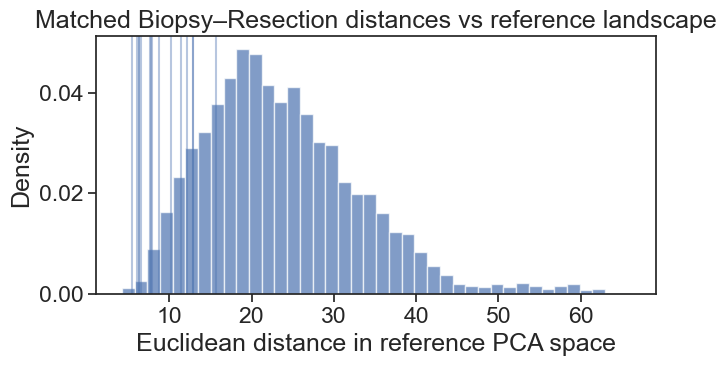

In [81]:
plt.figure(figsize=(7, 4))

plt.hist(
    ref_pairwise_distances,
    bins=40,
    alpha=0.7,
    density=True,
    label="Class reference pairwise distances",
)

for d in matched_refspace_benchmarked["matched_distance"]:
    plt.axvline(d, alpha=0.4)

plt.xlabel("Euclidean distance in reference PCA space")
plt.ylabel("Density")
plt.title("Matched Biopsy–Resection distances vs reference landscape")
plt.tight_layout()
plt.show()

## 10. Patient-blocked permutation helper

Define the exact within-patient label-swap test used for the reference and all-sample PCA analyses.

In [84]:
def exhaustive_patient_blocked_collection_test(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Exact patient-blocked permutation test for paired Biopsy/Resection PCA scores.
    Enumerates all 2^n within-patient label swaps.

    Suitable when n_pairs is modest, e.g. <= 20.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    keep_samples = []
    patients_ordered = []

    for patient, m in meta.groupby(patient_col):
        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) == 1 and len(resection_samples) == 1:
            keep_samples.extend([biopsy_samples[0], resection_samples[0]])
            patients_ordered.append(patient)

    meta = meta.loc[keep_samples].copy()
    Y = scores.loc[keep_samples, pc_cols].values

    patient_dummies = pd.get_dummies(meta[patient_col], drop_first=False)
    X_patient = patient_dummies.values.astype(float)

    collection_observed = (
        meta[sample_type_col].values == resection_label
    ).astype(float).reshape(-1, 1)

    def rss_multivariate_lm(Y, X):
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        resid = Y - X @ beta
        rss = np.sum(resid ** 2)
        rank = np.linalg.matrix_rank(X)
        df_resid = Y.shape[0] - rank
        return rss, df_resid, rank

    rss_patient, df_patient, rank_patient = rss_multivariate_lm(Y, X_patient)

    X_full_observed = np.column_stack([X_patient, collection_observed])
    rss_full_obs, df_full, rank_full = rss_multivariate_lm(Y, X_full_observed)

    ss_collection_obs = rss_patient - rss_full_obs
    partial_R2_obs = ss_collection_obs / rss_patient

    n_pairs = len(patients_ordered)

    perm_R2 = []

    # Precompute sample indices for each patient
    patient_to_indices = {
        patient: np.where(meta[patient_col].values == patient)[0]
        for patient in patients_ordered
    }

    for swap_pattern in itertools.product([0, 1], repeat=n_pairs):

        collection_perm = collection_observed.copy()

        for patient, swap in zip(patients_ordered, swap_pattern):
            if swap == 1:
                idx = patient_to_indices[patient]
                collection_perm[idx] = 1 - collection_perm[idx]

        X_perm = np.column_stack([X_patient, collection_perm])
        rss_perm_full, _, _ = rss_multivariate_lm(Y, X_perm)

        ss_perm_collection = rss_patient - rss_perm_full
        perm_R2.append(ss_perm_collection / rss_patient)

    perm_R2 = np.array(perm_R2)

    exact_p = np.mean(perm_R2 >= partial_R2_obs - 1e-12)

    result = {
        "n_pairs": n_pairs,
        "n_samples": meta.shape[0],
        "n_pcs": len(pc_cols),
        "observed_partial_R2": partial_R2_obs,
        "observed_partial_R2_percent": 100 * partial_R2_obs,
        "exact_permutation_p_value": exact_p,
        "n_total_permutations": len(perm_R2),
        "n_permutations_ge_observed": int(np.sum(perm_R2 >= partial_R2_obs - 1e-12)),
        "max_permuted_partial_R2": np.max(perm_R2),
        "max_permuted_partial_R2_percent": 100 * np.max(perm_R2),
    }

    return result, perm_R2

## 11. Paired-distance helper

Define the paired Euclidean-distance and patient-centroid calculation used in Figure 5 and Supplementary Figure 7.

In [89]:
def paired_distance_magnitude(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates paired biopsy-to-resection distances and patient centroids
    in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    pair_rows = []
    centroid_rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        b_vec = scores.loc[b, pc_cols].values.astype(float)
        r_vec = scores.loc[r, pc_cols].values.astype(float)

        diff = r_vec - b_vec
        dist = np.linalg.norm(diff)

        centroid = (b_vec + r_vec) / 2

        row = {
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "paired_distance": dist,
        }

        for pc, value in zip(pc_cols, diff):
            row[f"{pc}_resection_minus_biopsy"] = value

        pair_rows.append(row)

        centroid_rows.append(
            pd.Series(centroid, index=pc_cols, name=patient)
        )

    paired_distances = pd.DataFrame(pair_rows)
    patient_centroids = pd.DataFrame(centroid_rows)

    return paired_distances, patient_centroids

## 12. Reference-space paired visualization

Visualize the paired study samples in the biopsy-derived reference PCA space. The study-only sensitivity branch used for the reviewer response was removed.

In [98]:
def plot_paired_pca(
    scores,
    meta,
    pca,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    title=None,
):
    meta = meta.loc[scores.index].copy()

    #plt.figure(figsize=(6, 5))
    fig, ax = plt.subplots(figsize=(6, 5))

    # Draw patient-pair connecting lines
    for patient, m in meta.groupby(patient_col):
        sample_ids = m.index.tolist()

        if len(sample_ids) >= 2:
#             plt.plot(
#                 scores.loc[sample_ids, "PC1"],
#                 scores.loc[sample_ids, "PC2"],
#                 alpha=0.4,
#                 linewidth=1,
#                 color='grey'
#             )
        
            h = sns.lineplot(scores.loc[sample_ids,:],
                             x='PC1', y='PC2',
                             color='gray', ax=ax)

    # Draw points by sample type
    for sample_type, idx in meta.groupby(sample_type_col).groups.items():
        idx = list(idx)

#         plt.scatter(
#             scores.loc[idx, "PC1"],
#             scores.loc[idx, "PC2"],
#             label=sample_type,
#             s=45,
#         )
        
        scores['Sample_type'] = scores.index.map(meta.Sample_type)
        #print(scores.head())
        g = sns.scatterplot(scores.loc[idx, :], x='PC1', y='PC2',
                            hue='Sample_type', ax=ax, s=150,
                            alpha=0.8, linewidth=0, hue_order=hue_order)
    
        
        
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')

    if title is not None:
        plt.title(title)
        
    plt.legend([],[], frameon=False)
    plt.tight_layout()
    plt.savefig(f'PCA_{title.replace(' ', '_')}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

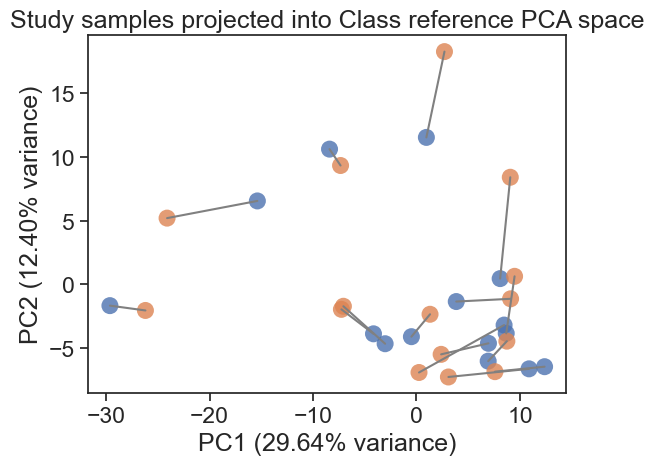

In [99]:
plot_paired_pca(
    scores=study_scores_refspace,
    meta=study_meta,
    pca=ref_pca,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    title="Study samples projected into Class reference PCA space",
)

In [103]:
# 1. Test in reference PCA space
refspace_test_result, refspace_perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=study_scores_refspace,
    meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=study_scores_refspace.columns[:10].tolist(),
)

refspace_test_result

{'n_pairs': 15,
 'n_samples': 30,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.20131007561734202),
 'observed_partial_R2_percent': np.float64(20.1310075617342),
 'exact_permutation_p_value': np.float64(0.01287841796875),
 'n_total_permutations': 32768,
 'n_permutations_ge_observed': 422,
 'max_permuted_partial_R2': np.float64(0.351800550757646),
 'max_permuted_partial_R2_percent': np.float64(35.1800550757646)}

## 13. PCA fitted on all samples

Fit an additional PCA using external reference and paired study samples together.

In [105]:
def fit_all_sample_pca(
    ref_expr,
    study_expr,
    n_top_genes=500,
    n_pcs=10,
    random_state=1,
):
    """
    Fits PCA on all samples:
        Class reference + study Biopsy + study Resection

    Inputs are samples x genes.

    Returns:
        all_scores
        ref_scores_allspace
        study_scores_allspace
        pca
        scaler
        top_genes
    """

    common_genes = ref_expr.columns.intersection(study_expr.columns)

    ref_common = ref_expr.loc[:, common_genes]
    study_common = study_expr.loc[:, common_genes]

    all_expr = pd.concat(
        [ref_common, study_common],
        axis=0
    )

    n_top_genes = min(n_top_genes, all_expr.shape[1])

    top_genes = (
        all_expr.var(axis=0)
        .sort_values(ascending=False)
        .head(n_top_genes)
        .index
    )

    scaler = StandardScaler(with_mean=True, with_std=True)

    all_scaled = scaler.fit_transform(all_expr.loc[:, top_genes])

    max_pcs = min(n_pcs, all_scaled.shape[0] - 1, all_scaled.shape[1])

    pca = PCA(n_components=max_pcs, random_state=random_state)

    all_scores_array = pca.fit_transform(all_scaled)

    pc_cols = [f"PC{i+1}" for i in range(max_pcs)]

    all_scores = pd.DataFrame(
        all_scores_array,
        index=all_expr.index,
        columns=pc_cols,
    )

    ref_scores_allspace = all_scores.loc[ref_expr.index]
    study_scores_allspace = all_scores.loc[study_expr.index]

    return (
        all_scores,
        ref_scores_allspace,
        study_scores_allspace,
        pca,
        scaler,
        top_genes,
    )

In [106]:
(
    all_scores,
    ref_scores_allspace,
    study_scores_allspace,
    all_pca,
    all_scaler,
    all_top_genes,
) = fit_all_sample_pca(
    ref_expr=ref_expr,
    study_expr=study_expr,
    n_top_genes=N_TOP_GENES,
    n_pcs=N_PCS,
    random_state=RANDOM_STATE,
)

pd.Series(
    all_pca.explained_variance_ratio_,
    index=all_scores.columns,
    name="explained_variance_ratio",
)

PC1     0.279639
PC2     0.116366
PC3     0.049756
PC4     0.038973
PC5     0.035137
PC6     0.030339
PC7     0.025581
PC8     0.022624
PC9     0.019493
PC10    0.018593
Name: explained_variance_ratio, dtype: float64

In [107]:
allspace_test_result, allspace_perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=study_scores_allspace,
    meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=study_scores_allspace.columns.tolist(),
)

allspace_test_result

{'n_pairs': 15,
 'n_samples': 30,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.20698327000004113),
 'observed_partial_R2_percent': np.float64(20.698327000004113),
 'exact_permutation_p_value': np.float64(0.01129150390625),
 'n_total_permutations': 32768,
 'n_permutations_ge_observed': 370,
 'max_permuted_partial_R2': np.float64(0.36189074097741614),
 'max_permuted_partial_R2_percent': np.float64(36.18907409774161)}

In [108]:
def plot_all_sample_pca(
    all_scores,
    meta,
    study_meta,
    pca,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    title="All-sample PCA",
    color_ref=None,
):
    plt.figure(figsize=(7, 6))

    meta_all = meta.loc[all_scores.index].copy()

    # Plot all samples by Sample_type
    for sample_type, idx in meta_all.groupby(sample_type_col).groups.items():
        idx = list(idx)

        alpha = 0.25 if sample_type == REF_LABEL else 0.85
        size = 25 if sample_type == REF_LABEL else 55

        plt.scatter(
            all_scores.loc[idx, "PC1"],
            all_scores.loc[idx, "PC2"],
            label=sample_type,
            alpha=alpha,
            s=size,
        )

    # Connect study biopsy/resection pairs
    for patient, m in study_meta.groupby(patient_col):
        sample_ids = m.index.tolist()

        if len(sample_ids) >= 2:
            plt.plot(
                all_scores.loc[sample_ids, "PC1"],
                all_scores.loc[sample_ids, "PC2"],
                alpha=0.5,
                color='grey',
                linewidth=1,
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig('PCA_class_fitted_on_all.pdf', dpi=300, bbox_inches='tight')
    plt.show()

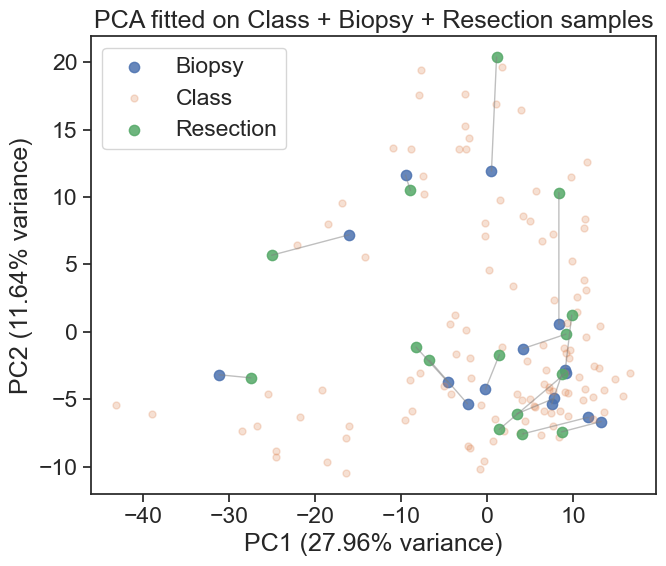

In [109]:
plot_all_sample_pca(
    all_scores=all_scores,
    meta=meta,
    pca=all_pca,
    study_meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    title="PCA fitted on Class + Biopsy + Resection samples",
)

In [110]:
def plot_all_sample_pca(
    all_scores,
    meta,
    study_meta,
    pca,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    tumor_content_col="percent_tumor",
    title="All-sample PCA",
    color_ref=None,
    hue_order=("Biopsy", "Resection"),
):
    fig, ax = plt.subplots(figsize=(7, 6))

    meta_all = meta.loc[all_scores.index].copy()
    palette = dict(
        zip(hue_order, sns.color_palette(n_colors=len(hue_order)))
    )

    # Connect study pairs first, so lines remain behind points
    order = {label: i for i, label in enumerate(hue_order)}

    for _, patient_meta in study_meta.groupby(patient_col):
        patient_meta = patient_meta[
            patient_meta[sample_type_col].isin(hue_order)
        ].sort_values(
            sample_type_col,
            key=lambda values: values.map(order),
        )

        sample_ids = [
            sample_id
            for sample_id in patient_meta.index
            if sample_id in all_scores.index
        ]

        if len(sample_ids) >= 2:
            ax.plot(
                all_scores.loc[sample_ids, "PC1"],
                all_scores.loc[sample_ids, "PC2"],
                color="0.7",
                alpha=0.6,
                linewidth=1,
                zorder=1,
            )

    # Reference samples coloured by tumour content
    ref_idx = meta_all.index[
        meta_all[sample_type_col] == REF_LABEL
    ]

    ref_tumor_content = pd.to_numeric(
        meta_all.loc[ref_idx, tumor_content_col],
        errors="coerce",
    )

    valid_ref = ref_tumor_content.notna()

    if valid_ref.any():
        ref_scatter = ax.scatter(
            all_scores.loc[ref_idx[valid_ref], "PC1"],
            all_scores.loc[ref_idx[valid_ref], "PC2"],
            c=ref_tumor_content.loc[valid_ref],
            cmap=color_ref or "viridis",
            vmin=0,
            vmax=100,
            alpha=0.65,
            s=30,
            linewidth=0,
            zorder=2,
        )

        colorbar = fig.colorbar(
            ref_scatter,
            ax=ax,
            pad=0.02,
        )
        colorbar.set_label("Tumour content (%)")
        colorbar.set_ticks(np.arange(0, 101, 20))

    # Reference samples with missing tumour content
    if (~valid_ref).any():
        ax.scatter(
            all_scores.loc[ref_idx[~valid_ref], "PC1"],
            all_scores.loc[ref_idx[~valid_ref], "PC2"],
            color="lightgrey",
            alpha=0.65,
            s=30,
            linewidth=0,
            zorder=2,
        )

    # Study samples in the requested Seaborn colour order
    for sample_type in hue_order:
        idx = meta_all.index[
            meta_all[sample_type_col] == sample_type
        ]

        if len(idx) == 0:
            continue

        ax.scatter(
            all_scores.loc[idx, "PC1"],
            all_scores.loc[idx, "PC2"],
            color=palette[sample_type],
            label=sample_type,
            alpha=0.9,
            s=55,
            edgecolor="white",
            linewidth=0.5,
            zorder=3,
        )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
    )
    ax.set_title(title)
    ax.legend(title=sample_type_col, frameon=False)

    fig.tight_layout()
    fig.savefig(
        "PCA_class_fitted_on_all.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

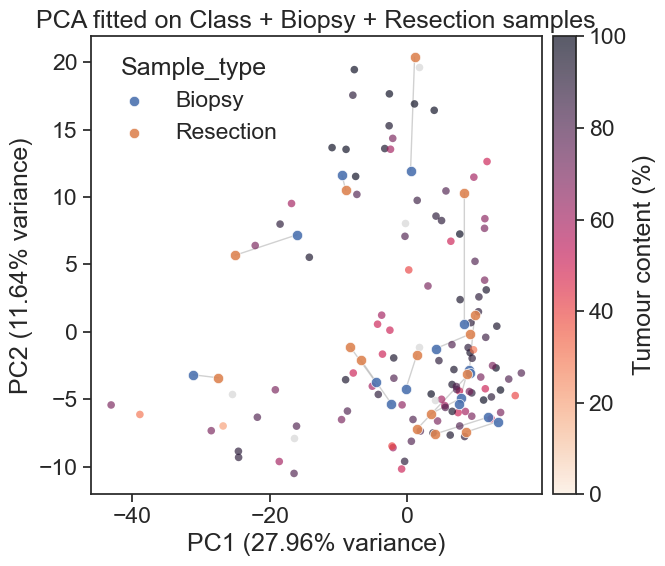

In [111]:
plot_all_sample_pca(
    all_scores=all_scores,
    meta=meta,
    pca=all_pca,
    study_meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    title="PCA fitted on Class + Biopsy + Resection samples",
    color_ref = sns.color_palette("rocket_r", as_cmap=True)
)

## 14. All-sample-space distance analysis

Benchmark paired distances and repeat the patient-blocked test in the all-sample PCA space.

In [112]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=all_scores,
    meta=meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=pc_cols,
)

paired_distances

,Patient ID,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,B,BSSE_QGF_129467,BSSE_QGF_129469,10,6.901796,-3.682976,2.589358,-2.399082,0.609416,-1.167003,1.145907,-0.768868,2.200624,3.435565,1.151828
1,D,BSSE_QGF_182053,BSSE_QGF_182083,10,6.351862,0.747402,4.029425,4.056469,-0.561529,0.287771,1.378787,0.191494,0.083213,-1.108951,1.877176
2,E,BSSE_QGF_145477,BSSE_QGF_145479,10,10.994901,-4.420331,3.231132,-8.931698,0.152166,-1.631587,-2.349856,-0.311213,-0.586887,0.424090,-1.518187
3,F,BSSE_QGF_145473,BSSE_QGF_145475,10,7.427270,-4.332907,-1.140357,-2.003475,2.928913,-3.717196,-0.974409,-0.287116,0.002244,-1.383560,-2.394516
4,H,BSSE_QGF_129477,BSSE_QGF_129481,10,12.702061,-7.620226,-1.232263,-4.295455,-1.832848,-3.864068,-6.428147,1.742953,-0.513132,-1.652103,-4.202743
5,I,BSSE_QGF_182073,BSSE_QGF_182107,10,8.105983,1.181039,2.190834,-6.482097,-1.172985,-1.532591,-0.828138,-2.090175,-1.823837,0.276992,2.304842
6,J,BSSE_QGF_182065,BSSE_QGF_182099,10,7.750008,4.969309,1.069998,0.246396,-2.706141,2.988290,-1.945455,-1.568141,-0.359103,1.695795,2.943021
7,K,BSSE_QGF_129475,BSSE_QGF_129479,10,17.221664,-0.002468,9.750520,-12.774765,0.558200,-3.352047,-3.746446,-2.766187,1.653342,0.245705,1.512962
8,L,BSSE_QGF_145461,BSSE_QGF_145463,10,5.266845,-4.602810,-0.770902,1.304396,0.692022,-1.183182,-0.691636,0.414041,-0.558842,-0.750342,-0.924197
9,N,BSSE_QGF_182055,BSSE_QGF_182085,10,8.359658,1.629770,2.572089,-6.770562,2.436868,0.302063,-2.460922,1.253481,0.259749,0.523268,-0.879413


In [113]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,15,10,8.105983,9.667633,23.945666,0.338516,0.0


In [114]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,Patient ID,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,B,BSSE_QGF_129467,BSSE_QGF_129469,10,6.901796,-3.682976,2.589358,-2.399082,0.609416,-1.167003,1.145907,-0.768868,2.200624,3.435565,1.151828,0.000000,0.288227
1,D,BSSE_QGF_182053,BSSE_QGF_182083,10,6.351862,0.747402,4.029425,4.056469,-0.561529,0.287771,1.378787,0.191494,0.083213,-1.108951,1.877176,0.000000,0.265261
2,E,BSSE_QGF_145477,BSSE_QGF_145479,10,10.994901,-4.420331,3.231132,-8.931698,0.152166,-1.631587,-2.349856,-0.311213,-0.586887,0.424090,-1.518187,3.809524,0.459160
3,F,BSSE_QGF_145473,BSSE_QGF_145475,10,7.427270,-4.332907,-1.140357,-2.003475,2.928913,-3.717196,-0.974409,-0.287116,0.002244,-1.383560,-2.394516,0.000000,0.310172
4,H,BSSE_QGF_129477,BSSE_QGF_129481,10,12.702061,-7.620226,-1.232263,-4.295455,-1.832848,-3.864068,-6.428147,1.742953,-0.513132,-1.652103,-4.202743,4.761905,0.530453
5,I,BSSE_QGF_182073,BSSE_QGF_182107,10,8.105983,1.181039,2.190834,-6.482097,-1.172985,-1.532591,-0.828138,-2.090175,-1.823837,0.276992,2.304842,0.000000,0.338516
6,J,BSSE_QGF_182065,BSSE_QGF_182099,10,7.750008,4.969309,1.069998,0.246396,-2.706141,2.988290,-1.945455,-1.568141,-0.359103,1.695795,2.943021,0.000000,0.323650
7,K,BSSE_QGF_129475,BSSE_QGF_129479,10,17.221664,-0.002468,9.750520,-12.774765,0.558200,-3.352047,-3.746446,-2.766187,1.653342,0.245705,1.512962,25.714286,0.719198
8,L,BSSE_QGF_145461,BSSE_QGF_145463,10,5.266845,-4.602810,-0.770902,1.304396,0.692022,-1.183182,-0.691636,0.414041,-0.558842,-0.750342,-0.924197,0.000000,0.219950
9,N,BSSE_QGF_182055,BSSE_QGF_182085,10,8.359658,1.629770,2.572089,-6.770562,2.436868,0.302063,-2.460922,1.253481,0.259749,0.523268,-0.879413,0.000000,0.349109


In [115]:
patient_col = 'Patient ID'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()
paired_q1 = plot_df[distance_col].quantile(0.25)
paired_q3 = plot_df[distance_col].quantile(0.75)

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)
between_q1 = np.quantile(between_patient_centroid_distances, 0.25)
between_q3 = np.quantile(between_patient_centroid_distances, 0.75)

In [116]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [117]:
plot_df_norm.mean(numeric_only=True)

paired_distance      9.667633
relative_distance    0.403732
dtype: float64

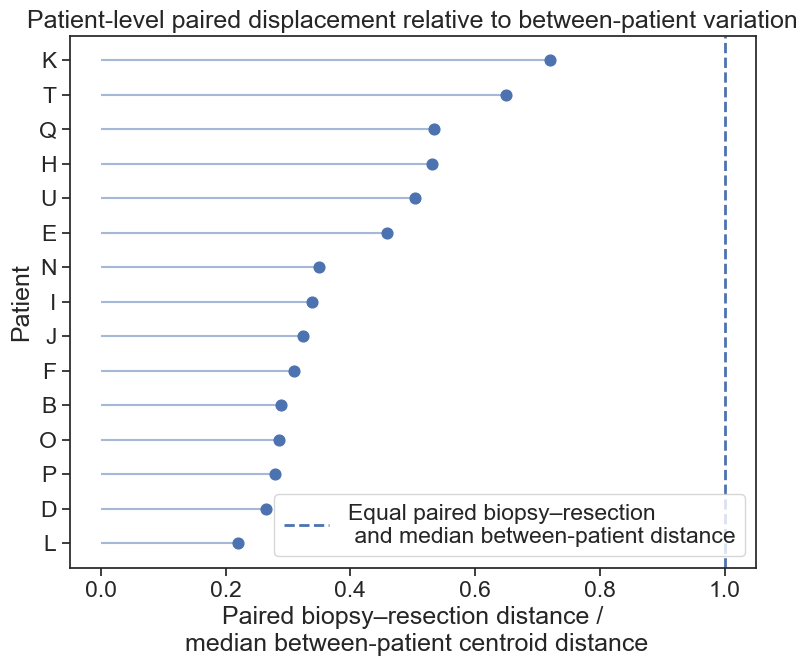

In [118]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)

# plt.axvline(
#     paired_median,
#     linewidth=1.5,
#     label="Median paired biopsy–resection distance"
# )

# plt.axvline(
#     between_median,
#     linewidth=1.5,
#     label="Median between-patient distance"
# )

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig('Distance_all_pca_class_hcc.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [119]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=all_scores,
    meta=meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=all_scores.columns.tolist(),
)

joint_test_result

{'n_pairs': 15,
 'n_samples': 30,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.20698327000004113),
 'observed_partial_R2_percent': np.float64(20.698327000004113),
 'exact_permutation_p_value': np.float64(0.01129150390625),
 'n_total_permutations': 32768,
 'n_permutations_ge_observed': 370,
 'max_permuted_partial_R2': np.float64(0.36189074097741614),
 'max_permuted_partial_R2_percent': np.float64(36.18907409774161)}

In [120]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv('Permutation_class_hcc.csv')
test_out

,0
n_pairs,15.000000
n_samples,30.000000
n_pcs,10.000000
observed_partial_R2,0.206983
observed_partial_R2_percent,20.698327
exact_permutation_p_value,0.011292
n_total_permutations,32768.000000
n_permutations_ge_observed,370.000000
max_permuted_partial_R2,0.361891
max_permuted_partial_R2_percent,36.189074


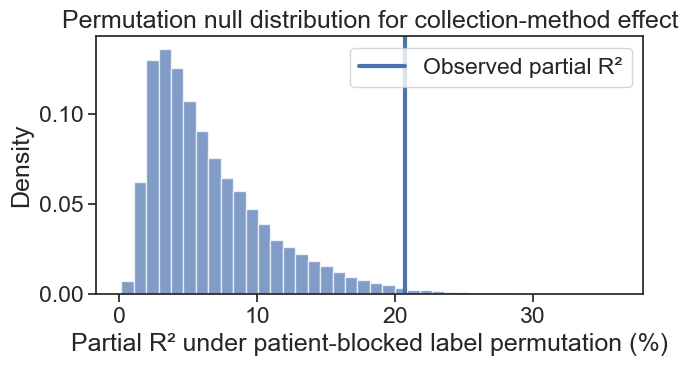

In [121]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig('Perm_all_pca_class.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Part II — Hoshida molecular-subtype analysis

Prepare Hoshida signature inputs, visualize subtype-associated genes, and summarize paired classifications.

In [122]:
df_hosh = pd.read_csv('Hoshida_supplementary_table_s3_extracted.csv')
df_hosh.index = df_hosh.symbol
df_hosh.head()

,subtype,gene_id,symbol,HC,NMF,k_means,description
symbol,,,,,,,
IQGAP1,S1,8826.0,IQGAP1,0.001,0.002,0.002,IQ motif containing GTPase activating protein 1
S100A11,S1,6282.0,S100A11,0.001,0.002,0.002,S100 calcium binding protein A11 (calgizzarin)
RAB31,S1,11031.0,RAB31,0.001,0.002,0.002,"RAB31, member RAS oncogene family"
CD37,S1,951.0,CD37,0.001,0.002,0.002,CD37 molecule
POSTN,S1,10631.0,POSTN,0.001,0.002,0.002,"periostin, osteoblast specific factor"


In [124]:
df_vst.head()

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55730,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55744,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
ENSG00000160072,9.947208,8.315006,9.366324,8.611853,8.280238,9.454422,8.630576,8.109481,7.662125,8.607415,8.008551,8.275576,8.028519,8.328708,8.479954,7.827881,8.133671,9.726703,10.141792,8.364017,8.386231,9.446644,9.309757,8.854076,9.649570,8.779498,8.250051,8.785812,7.872682,8.784672,8.647352,9.024374,7.761765,9.830601,8.551253,9.394823,9.053806,9.436272,7.732782,8.884686,9.146358,8.871385,9.878314,8.941230,8.873540,8.685743,9.408927,9.304361,10.184889,9.230953,9.367732,11.588219,8.452616,10.048388,8.450484,8.143928,8.479038,8.364525,8.541438,9.648479,8.779591,8.466558,8.289386,7.143609,9.379221,8.854416,8.675203,8.625572,8.690286,7.924961,8.366675,9.877143,8.331734,9.149815,8.955750,8.163630,9.170410,8.804561,8.676626,10.058219,8.577251,8.753560,8.549170,8.948068,8.452331,9.090693,6.854181,10.958107,7.890065,8.549630,8.434485,7.443263,8.347878,8.463255,10.159188,10.701220,8.587549,8.033665,8.300676,8.602060,8.275481,8.481925,8.575301,8.165372,10.156090,8.004824,7.853804,10.604790,8.165346,8.254389,9.105497,8.441718,9.134733,7.666843,7.556930,7.964045,7.819865,7.826508,9.390555,8.404532,8.536181,8.655999,9.056851,9.053807,7.709783,9.036308,9.066247,7.662499,8.331963,8.340294,8.540616,7.417855,8.830665,8.429540,9.158646,8.587468,7.967617,11.164863,8.952892,7.621156,10.018437,10.094875,8.337857,10.219323,9.144888
ENSG00000142611,5.173171,5.085889,8.990320,5.598876,7.842689,5.143404,7.323280,5.179987,5.072180,5.585443,6.561339,5.551798,6.638801,5.567792,5.147957,5.476533,5.285056,5.437510,5.763162,5.167942,5.789396,6.494375,7.736972,6.683984,5.832453,5.832723,5.185233,5.415152,5.359316,5.211743,6.623703,7.254472,6.663578,5.133403,5.308826,5.634719,5.906175,5.995581,5.181231,7.148016,6.063522,5.651808,5.143726,5.862829,5.712934,5.261013,5.550384,5.058659,5.629051,5.205214,5.810572,6.393214,

## 15. Map study expression to gene symbols

Attach gene symbols to the paired-study VST matrix for Hoshida subtype classification and heatmap generation.

In [126]:
# Add Gene Names
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_vst_ = df_vst.reset_index(names='Geneid').copy()
    
df_vst_['Gene'] = df_vst_['Geneid'].map(loaded_dict)
df_vst_.Gene = df_vst_.Gene.replace('', np.nan)
df_vst_.index = df_vst_.Geneid
df_vst_ = df_vst_.drop('Geneid', axis=1)

In [130]:
df_vst_.index = df_vst_.Gene
df_vst_ = df_vst_.drop('Gene', axis=1)
#df_vst_.to_csv('hoshida_input_07042026.csv')

In [131]:
# your vst matrix
df = df_vst_.copy()

# Ensure gene IDs are strings
df.index = df.index.astype(str)

# Add required columns
gct = df.copy()
gct.insert(0, "Description", "NA")
gct.insert(0, "Name", gct.index)

# Reset index (since Name now holds gene IDs)
gct = gct.reset_index(drop=True)

# Write GCT
# with open("hoshida_input_07042026.gct", "w") as f:
#     f.write("#1.2\n")
#     f.write(f"{gct.shape[0]}\t{gct.shape[1]-2}\n")  # exclude Name + Description
#     gct.to_csv(f, sep="\t", index=False)

## 16. Prepare Hoshida signature matrices

Read the signature definitions and create the expression subsets used for classification.

In [133]:
df = pd.read_csv("Hoshida_supplementary_table_s3_extracted.csv")
print(df.columns)
print(df.head())

Index(['subtype', 'gene_id', 'symbol', 'HC', 'NMF', 'k_means', 'description'], dtype='object')
  subtype  gene_id   symbol     HC    NMF  k_means  \
0      S1   8826.0   IQGAP1  0.001  0.002    0.002   
1      S1   6282.0  S100A11  0.001  0.002    0.002   
2      S1  11031.0    RAB31  0.001  0.002    0.002   
3      S1    951.0     CD37  0.001  0.002    0.002   
4      S1  10631.0    POSTN  0.001  0.002    0.002   

                                       description  
0  IQ motif containing GTPase activating protein 1  
1   S100 calcium binding protein A11 (calgizzarin)  
2                RAB31, member RAS oncogene family  
3                                    CD37 molecule  
4            periostin, osteoblast specific factor  


In [134]:
sig = df.copy()

# map class labels to integers if needed
class_map = {"S1": 1, "S2": 2, "S3": 3}
sig["Class"] = sig["subtype"].map(class_map)

sig_out = pd.DataFrame({
    "Probe": sig["symbol"].astype(str),
    "Gene": sig["symbol"].astype(str),
    "Class": sig["Class"],
    "Weight": 1
})

sig_out = sig_out.dropna()
sig_out = sig_out.drop_duplicates(subset=["Probe"])

#sig_out.to_csv("hoshida_ntp_classes.txt", sep="\t", index=False)

In [136]:
df_vst_hosh = df_vst_[df_vst_.index.isin(df_hosh.symbol)].copy()
df_vst_hosh.shape

(564, 145)

In [137]:
df_hosh.shape

(615, 7)

In [139]:
df_vst_hosh['subtype'] = df_vst_hosh.index.map(df_hosh.subtype)
df_vst_hosh.head()

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55730,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55744,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117,subtype
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SLC2A5,6.326940,6.130152,11.031251,6.807705,6.995815,5.796129,5.459670,6.900128,7.566700,6.194325,7.518384,5.551798,7.862968,6.041875,6.695190,6.039361,5.966558,8.726075,8.093181,5.502561,8.065155,9.965020,10.832702,5.449745,5.038670,8.665282,6.992361,5.735764,7.633317,5.743588,10.361230,6.127311,8.621037,4.980341,6.537623,5.853294,5.494308,8.555034,5.819341,6.014033,5.870338,5.794237,6.041359,6.369089,7.795310,9.462697,9.203882,5.158985,5.483454,6.312808,5.965444,8.832588,5.634053,5.497376,6.233298,5.082565,6.170698,7.920792,9.460508,6.765685,7.120132,10.699346,6.634034,5.646643,6.071171,5.837543,6.433041,11.947813,5.876900,5.320088,6.647118,7.785771,6.447385,7.644070,5.494693,5.318235,6.863476,7.973513,6.126263,5.801940,9.241736,5.734202,5.910263,8.975688,6.807516,10.789215,5.028206,5.896834,6.489970,8.264358,6.402164,6.230051,6.381279,5.657859,7.465152,7.986577,7.957938,6.995213,6.002822,7.095969,7.899697,5.716060,6.634450,5.789475,7.393960,7.106793,5.328767,11.201739,12.987147,7.479168,6.533789,5.672287,7.581425,7.169042,5.974510,8.720050,5.447962,6.703820,6.571239,10.258464,6.487927,8.127168,9.518038,9.026636,5.625803,10.526960,9.228434,6.977809,5.329089,7.197203,10.899241,5.958287,7.453795,8.983405,5.815282,8.403644,5.789531,7.285937,7.333393,6.510171,8.837738,8.361220,5.992936,8.500366,6.344466,S1
ALDH4A1,13.792359,12.499975,13.323540,12.864705,10.365845,12.831022,14.006626,11.728304,11.035666,13.526903,12.919525,13.459089,12.225766,14.384994,13.884559,13.486164,13.398123,11.760525,11.200936,13.298604,11.994429,14.119372,13.594284,13.467505,12.477379,13.522141,12.573620,13.716274,11.666367,13.647656,12.047575,13.130535,13.774

In [141]:
df_vst_hosh = df_vst_hosh.sort_values('subtype')

## 17. Signature heatmaps

Build subtype, sample-type, and patient annotations for Hoshida gene-expression heatmaps.

In [142]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [143]:
lut = {'S1':sns.color_palette('colorblind')[3],
       'S2':sns.color_palette('colorblind')[0],
       'S3':sns.color_palette('colorblind')[8]}
lut

{'S1': (0.8352941176470589, 0.3686274509803922, 0.0),
 'S2': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 'S3': (0.9254901960784314, 0.8823529411764706, 0.2)}

In [144]:
lut_cols = {'Biopsy': sns.color_palette()[0],
           'Resection': sns.color_palette()[1]}

In [145]:
metadata[metadata.Sample_type != 'Class']['Patient ID'].unique()

array(['B', 'K', 'H', 'L', 'F', 'E', 'D', 'N', 'J', 'O', 'Q', 'I', 'T',
       'U', 'P'], dtype=object)

In [146]:
lut_cols_pat = {'Biopsy': sns.color_palette()[0],
           'Resection': sns.color_palette()[1]}

In [148]:
cols = metadata[metadata.Sample_type != 'Class'].Seq_id.tolist()

In [149]:
metadata[metadata.Sample_type != 'Class']

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
Seq_id,,,,,,
BSSE_QGF_129467,B,59.0,M,BSSE_QGF_129467,Biopsy,NaN
BSSE_QGF_129469,B,59.0,M,BSSE_QGF_129469,Resection,NaN
BSSE_QGF_129475,K,71.0,M,BSSE_QGF_129475,Biopsy,NaN
BSSE_QGF_129477,H,69.0,F,BSSE_QGF_129477,Biopsy,NaN
BSSE_QGF_129479,K,71.0,M,BSSE_QGF_129479,Resection,NaN
BSSE_QGF_129481,H,69.0,F,BSSE_QGF_129481,Resection,NaN
BSSE_QGF_145461,L,66.0,F,BSSE_QGF_145461,Biopsy,NaN
BSSE_QGF_145463,L,66.0,F,BSSE_QGF_145463,Resection,NaN
BSSE_QGF_145473,F,49.0,M,BSSE_QGF_145473,Biopsy,NaN


C:\Users\Fredrik\miniconda3\envs\EDA\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


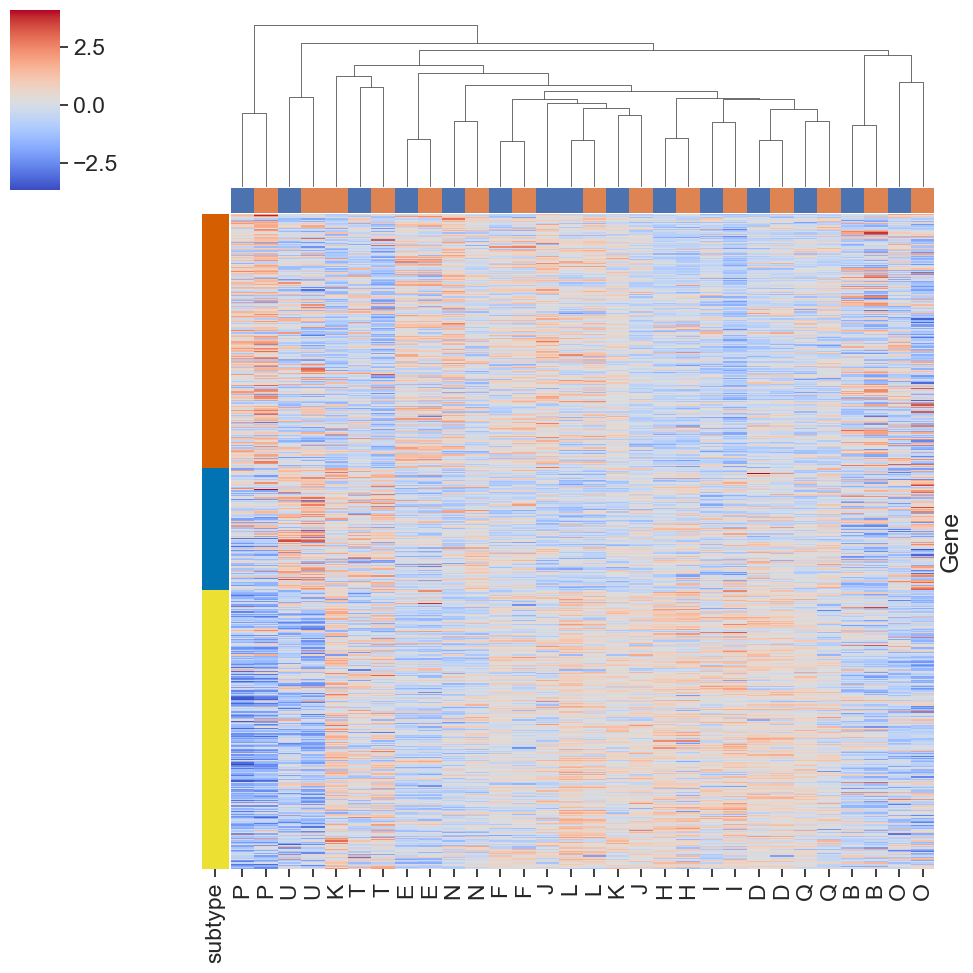

In [150]:
df_heatmap = df_vst_hosh[cols]
df_heatmap.columns = df_heatmap.columns.map(metadata[metadata.Sample_type != 'Class']['Patient ID'])

sns.clustermap(df_heatmap, row_colors=df_vst_hosh.subtype.map(lut),
              row_cluster=False, yticklabels=False, xticklabels=True,
               z_score=0, cmap='coolwarm', 
               col_colors=[metadata[metadata.Sample_type != 'Class'].Sample_type.map(lut_cols)])

In [151]:
df_vst_hosh

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55730,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55744,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117,subtype
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SLC2A5,6.326940,6.130152,11.031251,6.807705,6.995815,5.796129,5.459670,6.900128,7.566700,6.194325,7.518384,5.551798,7.862968,6.041875,6.695190,6.039361,5.966558,8.726075,8.093181,5.502561,8.065155,9.965020,10.832702,5.449745,5.038670,8.665282,6.992361,5.735764,7.633317,5.743588,10.361230,6.127311,8.621037,4.980341,6.537623,5.853294,5.494308,8.555034,5.819341,6.014033,5.870338,5.794237,6.041359,6.369089,7.795310,9.462697,9.203882,5.158985,5.483454,6.312808,5.965444,8.832588,5.634053,5.497376,6.233298,5.082565,6.170698,7.920792,9.460508,6.765685,7.120132,10.699346,6.634034,5.646643,6.071171,5.837543,6.433041,11.947813,5.876900,5.320088,6.647118,7.785771,6.447385,7.644070,5.494693,5.318235,6.863476,7.973513,6.126263,5.801940,9.241736,5.734202,5.910263,8.975688,6.807516,10.789215,5.028206,5.896834,6.489970,8.264358,6.402164,6.230051,6.381279,5.657859,7.465152,7.986577,7.957938,6.995213,6.002822,7.095969,7.899697,5.716060,6.634450,5.789475,7.393960,7.106793,5.328767,11.201739,12.987147,7.479168,6.533789,5.672287,7.581425,7.169042,5.974510,8.720050,5.447962,6.703820,6.571239,10.258464,6.487927,8.127168,9.518038,9.026636,5.625803,10.526960,9.228434,6.977809,5.329089,7.197203,10.899241,5.958287,7.453795,8.983405,5.815282,8.403644,5.789531,7.285937,7.333393,6.510171,8.837738,8.361220,5.992936,8.500366,6.344466,S1
CSRP3,4.607321,4.607321,5.024450,4.607321,5.010945,4.607321,4.607321,4.878654,4.607321,5.051421,4.607321,4.607321,4.868474,5.168600,4.607321,4.607321,4.607321,4.607321,5.110900,4.607321,5.035463,5.010900,4.946717,4.929600,4.607321,4.607321,4.867151,5.149738,4.607321,4.607321,4.967971,4.607321,4.858436,4.607321,4.923510,4.607321,4.90

C:\Users\Fredrik\miniconda3\envs\EDA\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\Fredrik\miniconda3\envs\EDA\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


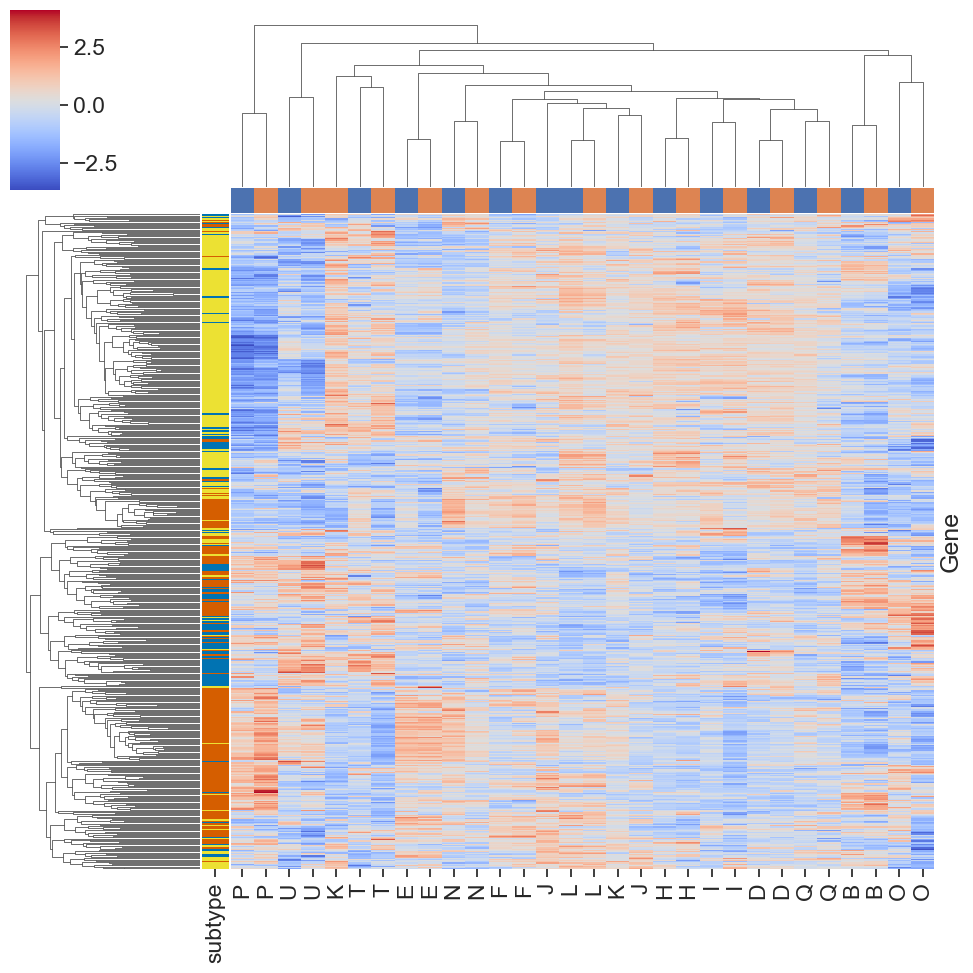

In [152]:
df_heatmap = df_vst_hosh[cols]
df_heatmap.columns = df_heatmap.columns.map(metadata[metadata.Sample_type != 'Class']['Patient ID'])

sns.clustermap(df_heatmap, row_colors=df_vst_hosh.subtype.map(lut),
              row_cluster=True, yticklabels=False, xticklabels=True,
               z_score=0, cmap='coolwarm', 
               col_colors=[metadata[metadata.Sample_type != 'Class'].Sample_type.map(lut_cols)])

## 18. Import and curate NTP classifications

Load precomputed Hoshida NTP results, apply the BH-FDR classification rule, and align results to study metadata.

In [153]:
hosh_res = pd.read_csv('Hoshida_classification_result.csv')

In [154]:
hosh_res.head()

,sample.names,predict.label,dist.to.template,dist.to.cls1.rank,nominal.p,BH.FDR,Bonferroni.p
0,BSSE_QGF_107014,2,0.733545,52,0.000333,0.000878,0.048317
1,BSSE_QGF_107024,2,0.740822,53,0.000333,0.000878,0.048317
2,BSSE_QGF_107028,1,0.835908,34,0.000333,0.000878,0.048317
3,BSSE_QGF_107037,3,0.644872,109,0.000333,0.000878,0.048317
4,BSSE_QGF_107047,1,0.862266,37,0.010330,0.011702,1.000000


In [156]:
hosh_res['predict.label'] = 'S' + hosh_res['predict.label'].astype(str)

In [157]:
hosh_res.index = hosh_res['sample.names']

In [158]:
hosh_res.head()

,sample.names,predict.label,dist.to.template,dist.to.cls1.rank,nominal.p,BH.FDR,Bonferroni.p
sample.names,,,,,,,
BSSE_QGF_107014,BSSE_QGF_107014,S2,0.733545,52,0.000333,0.000878,0.048317
BSSE_QGF_107024,BSSE_QGF_107024,S2,0.740822,53,0.000333,0.000878,0.048317
BSSE_QGF_107028,BSSE_QGF_107028,S1,0.835908,34,0.000333,0.000878,0.048317
BSSE_QGF_107037,BSSE_QGF_107037,S3,0.644872,109,0.000333,0.000878,0.048317
BSSE_QGF_107047,BSSE_QGF_107047,S1,0.862266,37,0.010330,0.011702,1.000000


In [159]:
hosh_res['predict.label'] = np.where(hosh_res['BH.FDR'] > 0.05, 'unclassifiable', hosh_res['predict.label'])

In [160]:
hosh_res.tail()

,sample.names,predict.label,dist.to.template,dist.to.cls1.rank,nominal.p,BH.FDR,Bonferroni.p
sample.names,,,,,,,
GFB_37107,GFB_37107,S1,0.899889,39,0.005332,0.006185,0.773076
GFB_37108,GFB_37108,S2,0.880607,68,0.001666,0.002065,0.241586
GFB_37111,GFB_37111,S1,0.726955,22,0.000333,0.000878,0.048317
GFB_37113,GFB_37113,S1,0.725467,21,0.000333,0.000878,0.048317
GFB_37117,GFB_37117,S1,0.699842,20,0.000333,0.000878,0.048317


In [161]:
lut

{'S1': (0.8352941176470589, 0.3686274509803922, 0.0),
 'S2': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 'S3': (0.9254901960784314, 0.8823529411764706, 0.2)}

In [162]:
lut['unclassifiable'] = sns.color_palette('colorblind')[7]

In [163]:
lut

{'S1': (0.8352941176470589, 0.3686274509803922, 0.0),
 'S2': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 'S3': (0.9254901960784314, 0.8823529411764706, 0.2),
 'unclassifiable': (0.5803921568627451,
  0.5803921568627451,
  0.5803921568627451)}

In [164]:
metadata[metadata.Sample_type != 'Class'].Sample_type.map(lut_cols)

Seq_id
BSSE_QGF_129467    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_129469    (0.8666666666666667, 0.5176470588235295, 0.321...
BSSE_QGF_129475    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_129477    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_129479    (0.8666666666666667, 0.5176470588235295, 0.321...
BSSE_QGF_129481    (0.8666666666666667, 0.5176470588235295, 0.321...
BSSE_QGF_145461    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_145463    (0.8666666666666667, 0.5176470588235295, 0.321...
BSSE_QGF_145473    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_145475    (0.8666666666666667, 0.5176470588235295, 0.321...
BSSE_QGF_145477    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_145479    (0.8666666666666667, 0.5176470588235295, 0.321...
BSSE_QGF_182053    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_182055    (0.2980392156862745, 0.4470588235294118, 0.690...
BSSE_QGF_182065    (0.29803

In [165]:
hosh_res['predict.label'].map(lut)

sample.names
BSSE_QGF_107014    (0.00392156862745098, 0.45098039215686275, 0.6...
BSSE_QGF_107024    (0.00392156862745098, 0.45098039215686275, 0.6...
BSSE_QGF_107028        (0.8352941176470589, 0.3686274509803922, 0.0)
BSSE_QGF_107037        (0.9254901960784314, 0.8823529411764706, 0.2)
BSSE_QGF_107047        (0.8352941176470589, 0.3686274509803922, 0.0)
BSSE_QGF_107058    (0.00392156862745098, 0.45098039215686275, 0.6...
BSSE_QGF_107063    (0.5803921568627451, 0.5803921568627451, 0.580...
BSSE_QGF_129467    (0.5803921568627451, 0.5803921568627451, 0.580...
BSSE_QGF_129469    (0.5803921568627451, 0.5803921568627451, 0.580...
BSSE_QGF_129475        (0.9254901960784314, 0.8823529411764706, 0.2)
BSSE_QGF_129477        (0.9254901960784314, 0.8823529411764706, 0.2)
BSSE_QGF_129479        (0.9254901960784314, 0.8823529411764706, 0.2)
BSSE_QGF_129481        (0.9254901960784314, 0.8823529411764706, 0.2)
BSSE_QGF_145461        (0.9254901960784314, 0.8823529411764706, 0.2)
BSSE_QGF_145463      

In [166]:
metadata[metadata.Sample_type != 'Class']['Patient ID'].sort_values().index

Index(['BSSE_QGF_129467', 'BSSE_QGF_129469', 'BSSE_QGF_182083',
       'BSSE_QGF_182053', 'BSSE_QGF_145477', 'BSSE_QGF_145479',
       'BSSE_QGF_145473', 'BSSE_QGF_145475', 'BSSE_QGF_129477',
       'BSSE_QGF_129481', 'BSSE_QGF_182107', 'BSSE_QGF_182073',
       'BSSE_QGF_182099', 'BSSE_QGF_182065', 'BSSE_QGF_129479',
       'BSSE_QGF_129475', 'BSSE_QGF_145463', 'BSSE_QGF_145461',
       'BSSE_QGF_182085', 'BSSE_QGF_182055', 'BSSE_QGF_182067',
       'BSSE_QGF_182101', 'BSSE_QGF_55730', 'BSSE_QGF_55744',
       'BSSE_QGF_182071', 'BSSE_QGF_182103', 'BSSE_QGF_182075',
       'BSSE_QGF_182105', 'BSSE_QGF_182077', 'BSSE_QGF_182111'],
      dtype='object', name='Seq_id')

In [167]:
metadata[metadata.Sample_type != 'Class'].sort_values(['Patient ID', 'Sample_type'])

,Patient ID,Age,Sex,Seq_id,Sample_type,percent_tumor
Seq_id,,,,,,
BSSE_QGF_129467,B,59.0,M,BSSE_QGF_129467,Biopsy,NaN
BSSE_QGF_129469,B,59.0,M,BSSE_QGF_129469,Resection,NaN
BSSE_QGF_182053,D,70.0,F,BSSE_QGF_182053,Biopsy,NaN
BSSE_QGF_182083,D,70.0,F,BSSE_QGF_182083,Resection,NaN
BSSE_QGF_145477,E,79.0,M,BSSE_QGF_145477,Biopsy,NaN
BSSE_QGF_145479,E,79.0,M,BSSE_QGF_145479,Resection,NaN
BSSE_QGF_145473,F,49.0,M,BSSE_QGF_145473,Biopsy,NaN
BSSE_QGF_145475,F,49.0,M,BSSE_QGF_145475,Resection,NaN
BSSE_QGF_129477,H,69.0,F,BSSE_QGF_129477,Biopsy,NaN


In [168]:
hosh_res.sort_values('dist.to.template')

,sample.names,predict.label,dist.to.template,dist.to.cls1.rank,nominal.p,BH.FDR,Bonferroni.p
sample.names,,,,,,,
BSSE_QGF_34371,BSSE_QGF_34371,S1,0.399214,1,0.000333,0.000878,0.048317
BSSE_QGF_55747,BSSE_QGF_55747,S3,0.431716,77,0.000333,0.000878,0.048317
BSSE_QGF_34375,BSSE_QGF_34375,S3,0.434089,78,0.000333,0.000878,0.048317
BSSE_QGF_34406,BSSE_QGF_34406,S3,0.438680,79,0.000333,0.000878,0.048317
BSSE_QGF_34439,BSSE_QGF_34439,S3,0.441769,80,0.000333,0.000878,0.048317
BSSE_QGF_55012,BSSE_QGF_55012,S3,0.447161,81,0.000333,0.000878,0.048317
BSSE_QGF_34369,BSSE_QGF_34369,S3,0.460854,82,0.000333,0.000878,0.048317
BSSE_QGF_34457,BSSE_QGF_34457,S3,0.472058,83,0.000333,0.000878,0.048317
BSSE_QGF_34385,BSSE_QGF_34385,S1,0.472922,2,0.000333,0.000878,0.048317


## 19. Annotated classification heatmap

Add continuous distance annotations and categorical sample/patient labels.

In [169]:
df_heatmap = df_vst_hosh[cols]
df_heatmap = df_heatmap.loc[:, metadata[metadata.Sample_type != 'Class'].sort_values(['Patient ID', 'Sample_type']).index]


# Ensure metadata is aligned to heatmap columns
meta = metadata[metadata.Sample_type != 'Class'].loc[df_heatmap.columns]

In [170]:
# Create continous color mappings

dist_to_template = hosh_res.loc[df_heatmap.columns, "dist.to.template"]
bh_fdr = hosh_res.loc[df_heatmap.columns, "BH.FDR"]

# Define continuous color mapping
vr_continuous_cmap = plt.cm.viridis
norm_vr = mpl.colors.Normalize(
    vmin=dist_to_template.min(),
    vmax=dist_to_template.max()
)

fdr_continuous_cmap = plt.cm.Blues
norm_fdr = mpl.colors.Normalize(
    vmin=bh_fdr.min(),
    vmax=bh_fdr.max()
)

dist_template_colors = dist_to_template.map(lambda x: vr_continuous_cmap(norm_vr(x)))
fdr_colors = bh_fdr.map(lambda x: fdr_continuous_cmap(norm_fdr(x)))

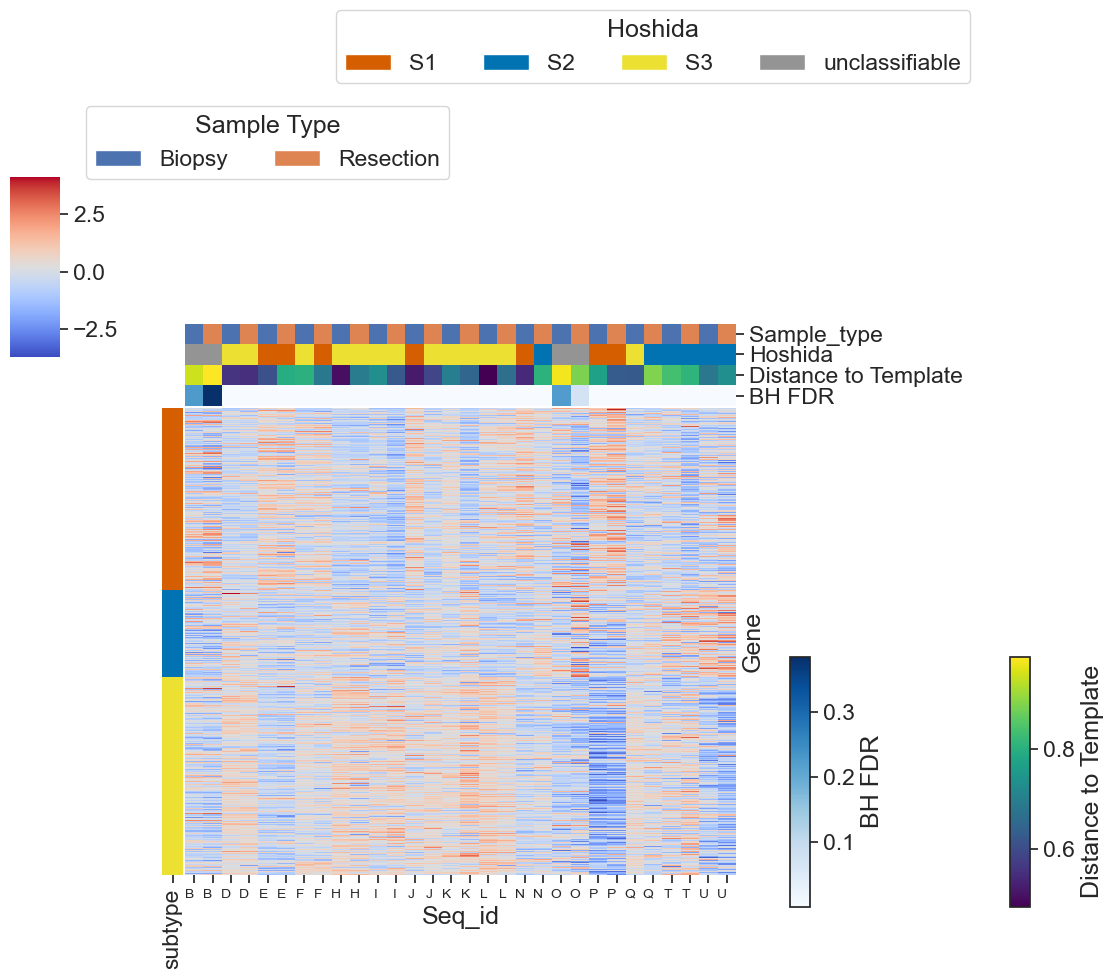

In [171]:

# Build color mappings
col_colors_df = pd.DataFrame({
    "Sample_type": meta.loc[df_heatmap.columns, "Sample_type"].map(lut_cols),
    "Hoshida": hosh_res.loc[df_heatmap.columns, "predict.label"].map(lut),
    "Distance to Template": dist_template_colors,
    "BH FDR": fdr_colors
}, index=df_heatmap.columns)

#df_heatmap.columns = df_heatmap.columns.map(metadata[metadata.Sample_type != 'Class']['Patient ID'])
g = sns.clustermap(df_heatmap, row_colors=df_vst_hosh.subtype.map(lut),
              row_cluster=False, col_cluster=False, yticklabels=False, xticklabels=True,
               z_score=0, cmap='coolwarm',
               col_colors=col_colors_df)

# --- Create legends ---
# Example: Sample_type legend
sample_type_legend = [
    Patch(facecolor=color, label=label)
    for label, color in lut_cols.items()
]

# Example: Hoshida legend
hoshida_legend = [
    Patch(facecolor=color, label=label)
    for label, color in lut.items()
]

leg1 = g.ax_col_dendrogram.legend(
    handles=sample_type_legend,
    title="Sample Type",
    loc="center",
    bbox_to_anchor=(0.15, 1.3),
    ncol=3
)

leg2 = g.ax_col_dendrogram.legend(
    handles=hoshida_legend,
    title="Hoshida",
    loc="center",
    bbox_to_anchor=(.85, 2),
    ncol=4
)

g.ax_col_dendrogram.add_artist(leg1)


ax = g.ax_heatmap
new_labels = df_heatmap.columns.map(metadata[metadata.Sample_type != 'Class']['Patient ID'])

ax.set_xticklabels(new_labels, rotation=0, ha="right", fontsize=10)

# Add colorbar for the continuous column annotation
sm = mpl.cm.ScalarMappable(cmap=vr_continuous_cmap, norm=norm_vr)
sm.set_array([])

cbar_ax = g.fig.add_axes([1.02, 0.25, 0.02, 0.25])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Distance to Template")

# Add colorbar for the continuous column annotation
sm = mpl.cm.ScalarMappable(cmap=fdr_continuous_cmap, norm=norm_fdr)
sm.set_array([])

cbar_ax = g.fig.add_axes([.8, 0.25, 0.02, 0.25])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("BH FDR")
#plt.savefig('heatmap_hoshida_results_20260407.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [172]:
4/13

# corresponding to an estimated discordance rate of 30.8% (95% Wilson CI: 12.7%–57.6%).

0.3076923076923077

## 20. Paired subtype concordance

Identify pairs retaining the same Hoshida label and export the curated classification table.

In [173]:
# Patients with same class
same_class_pats = ['D', 'E', 'H', 'I', 'K', 'L', 'P', 'T', 'U']

# Unclassifiable samples
un_class_pats = ['B', 'P']

meta_f = metadata[metadata.Sample_type != 'Class'].sort_values(['Patient ID', 'Sample_type']).copy()
#meta_f = meta_f[meta_f['Patient ID'].isin(same_class_pats)]
#meta_f = meta_f[~meta_f['Patient ID'].isin(un_class_pats)]


hosh_res_ = hosh_res.copy()
hosh_res_ = hosh_res_.loc[meta_f.index.tolist(),:]
hosh_res_['Patient ID'] = hosh_res_.index.map(meta_f['Patient ID'])
hosh_res_['Sample_type'] = hosh_res_.index.map(meta_f['Sample_type'])
hosh_res_.head()

,sample.names,predict.label,dist.to.template,dist.to.cls1.rank,nominal.p,BH.FDR,Bonferroni.p,Patient ID,Sample_type
sample.names,,,,,,,,,
BSSE_QGF_129467,BSSE_QGF_129467,unclassifiable,0.947471,42,0.214928,0.227479,1.000000,B,Biopsy
BSSE_QGF_129469,BSSE_QGF_129469,unclassifiable,0.986015,44,0.369210,0.385147,1.000000,B,Resection
BSSE_QGF_182053,BSSE_QGF_182053,S3,0.558526,92,0.000333,0.000878,0.048317,D,Biopsy
BSSE_QGF_182083,BSSE_QGF_182083,S3,0.550142,91,0.000333,0.000878,0.048317,D,Resection
BSSE_QGF_145477,BSSE_QGF_145477,S1,0.606622,11,0.000333,0.000878,0.048317,E,Biopsy


In [174]:
hosh_res_.to_csv('Hoshida_results_2026_sep.csv')